In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
(x_train, y_train), _ = tf.keras.datasets.mnist.load_data()

# Select 200 images per digit
selected_x, selected_y = [], []

for digit in range(10):
    idx = np.where(y_train == digit)[0][:200]
    selected_x.append(x_train[idx])
    selected_y.append(y_train[idx])

x = np.concatenate(selected_x, axis=0)
y = np.concatenate(selected_y, axis=0)

print("Images shape:", x.shape)
print("Labels shape:", y.shape)

Images shape: (2000, 28, 28)
Labels shape: (2000,)


In [ ]:
# Normalize
x = x.astype("float32") / 255.0

# Add channel dimension
x = x[..., np.newaxis]    # (2000, 28, 28, 1)

# One-hot encode labels
y = tf.keras.utils.to_categorical(y, 10)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten,
    Dense, BatchNormalization, Activation
)
model = Sequential()

# ---------- CNN PART ----------
model.add(Conv2D(32, (3,3), padding='same', input_shape=(28,28,1)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

# ---------- DNN PART ----------
model.add(Dense(512))
model.add(BatchNormalization())
model.add(Activation('relu'))

#hidden layer 1
model.add(Dense(512))
model.add(Activation('relu'))

#hidden layer 2
model.add(Dense(512))
model.add(Activation('relu'))

# ---------- OUTPUT ----------
model.add(Dense(10, activation='softmax'))

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    x, y,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)
model.summary()

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 97ms/step - accuracy: 0.7694 - loss: 0.7210 - val_accuracy: 0.0000e+00 - val_loss: 9.0933
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 112ms/step - accuracy: 0.9516 - loss: 0.1465 - val_accuracy: 0.0000e+00 - val_loss: 14.0065
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - accuracy: 0.9914 - loss: 0.0341 - val_accuracy: 0.0000e+00 - val_loss: 17.9479
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step - accuracy: 0.9819 - loss: 0.0600 - val_accuracy: 0.0000e+00 - val_loss: 16.9136
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step - accuracy: 0.9858 - loss: 0.0485 - val_accuracy: 0.0000e+00 - val_loss: 19.1048
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - accuracy: 0.9869 - loss: 0.0404 - val_accuracy: 0.0000e+00 - val_loss: 23.2194
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - accuracy: 0.9864 - loss: 0.0305 - val_accuracy: 0.0000e+00 - val_loss: 14.3934
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - accuracy: 0.9942 -

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 512)            │     1,606,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,471,072 (24.69 MB)

 Trainable params: 2,156,618 (8.23 MB)

 Non-trainable params: 1,216 (4.75 KB)

 Optimizer params: 4,313,238 (16.45 MB)

NameError: name 'x_test' is not defined

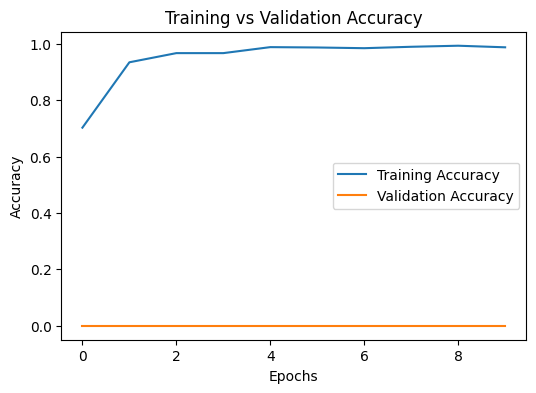

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()



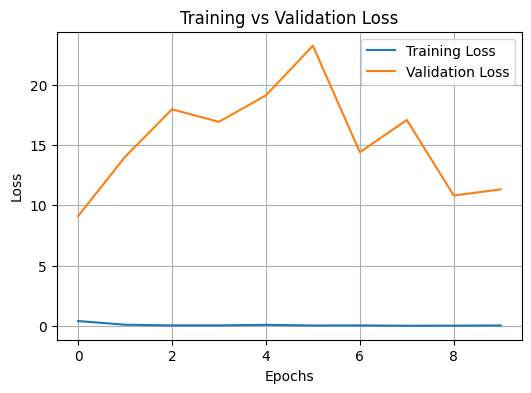

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

**by using L2 regularization**

Images shape: (2000, 28, 28)
Labels shape: (2000,)
Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 89ms/step - accuracy: 0.4921 - loss: 2.9037 - val_accuracy: 0.0000e+00 - val_loss: 13.7408
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - accuracy: 0.9302 - loss: 0.9330 - val_accuracy: 0.0000e+00 - val_loss: 11.8596
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - accuracy: 0.9673 - loss: 0.6807 - val_accuracy: 0.0000e+00 - val_loss: 13.0974
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.9683 - loss: 0.5972 - val_accuracy: 0.0000e+00 - val_loss: 9.8525
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - accuracy: 0.9884 - loss: 0.4977 - val_accuracy: 0.0000e+00 - val_loss: 13.7702
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - accuracy: 0.9865 - loss: 0.4350 - val_accuracy: 0.0000e+00 - val_loss: 13.6399
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.9870 - loss: 0.3910 - val_accuracy: 0.0000e+00 - val_loss: 11.9101
Epoch 8/10
50/50 ━━━━━━━

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_22 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 512)            │     1,606,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,466,208 (24.67 MB)

 Trainable params: 2,155,402 (8.22 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,310,806 (16.44 MB)

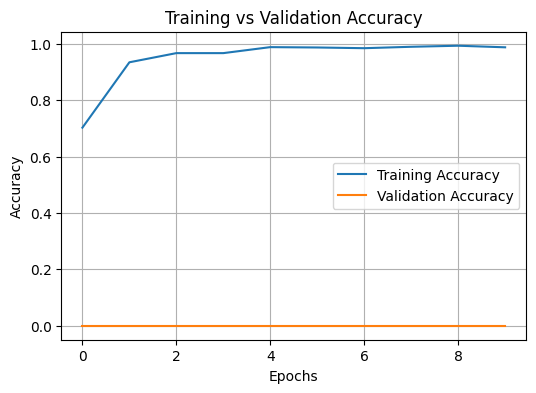

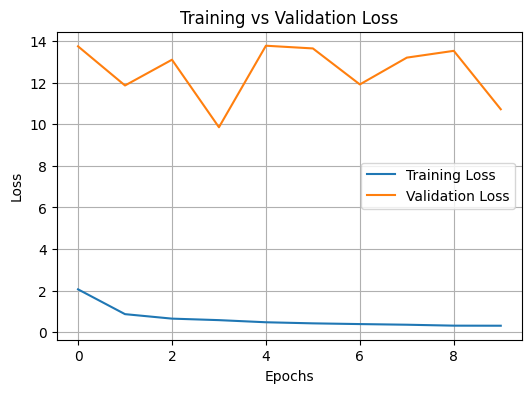

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# get dataset
(x_train, y_train), _ = tf.keras.datasets.mnist.load_data()

# Select 200 images per digit
selected_x, selected_y = [], []

for digit in range(10):
    idx = np.where(y_train == digit)[0][:200]
    selected_x.append(x_train[idx])
    selected_y.append(y_train[idx])

x = np.concatenate(selected_x, axis=0)
y = np.concatenate(selected_y, axis=0)

print("Images shape:", x.shape)
print("Labels shape:", y.shape)

#----------------------------------------------------------------------------------------
# Normalize
x = x.astype("float32") / 255.0

# Add channel dimension
x = x[..., np.newaxis]    # (2000, 28, 28, 1)

# One-hot encode labels
y = tf.keras.utils.to_categorical(y, 10)


#-----------------------------------------------------------------------------------
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten,
    Dense, Activation
)
from tensorflow.keras.regularizers import L2
model = Sequential()

# ---------- CNN PART ----------
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation
from tensorflow.keras.regularizers import l2

model = Sequential()

# ---------- CNN PART ----------
model.add(Conv2D(
    32, (3,3), padding='same',
    activation='relu',
    kernel_regularizer=l2(0.001),
    input_shape=(28,28,1)
))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(
    64, (3,3), padding='same',
    activation='relu',
    kernel_regularizer=l2(0.001)
))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

# ---------- DNN PART ----------
model.add(Dense(512, activation='relu',kernel_regularizer=l2(0.001)))

# hidden layer1
model.add(Dense(512, activation='relu', kernel_regularizer=l2(0.001)))

#hidden layer2
model.add(Dense(512, activation='relu', kernel_regularizer=l2(0.001)))

# ---------- OUTPUT ----------
model.add(Dense(10, activation='softmax'))



model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    x, y,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)
model.summary()



plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()




plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

**using Dropout

Training Images shape: (2000, 28, 28)
Training Labels shape: (2000,)
Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 103ms/step - accuracy: 0.4058 - loss: 1.6339 - val_accuracy: 0.0000e+00 - val_loss: 7.2027
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 120ms/step - accuracy: 0.8973 - loss: 0.3148 - val_accuracy: 0.0000e+00 - val_loss: 7.9297
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - accuracy: 0.9515 - loss: 0.1506 - val_accuracy: 0.0000e+00 - val_loss: 8.3902
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 140ms/step - accuracy: 0.9740 - loss: 0.1149 - val_accuracy: 0.0000e+00 - val_loss: 10.0312
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - accuracy: 0.9768 - loss: 0.0678 - val_accuracy: 0.0000e+00 - val_loss: 8.1835
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - accuracy: 0.9784 - loss: 0.0588 - val_accuracy: 0.0000e+00 - val_loss: 11.0549
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 101ms/step - accuracy: 0.9887 - loss: 0.0329 - val_accuracy: 0.0000e+00 - val_loss: 12.8501
Epoch 

Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_32 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_16 (Flatten)            │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 512)            │     1,606,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_65 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_66 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,466,208 (24.67 MB)

 Trainable params: 2,155,402 (8.22 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,310,806 (16.44 MB)

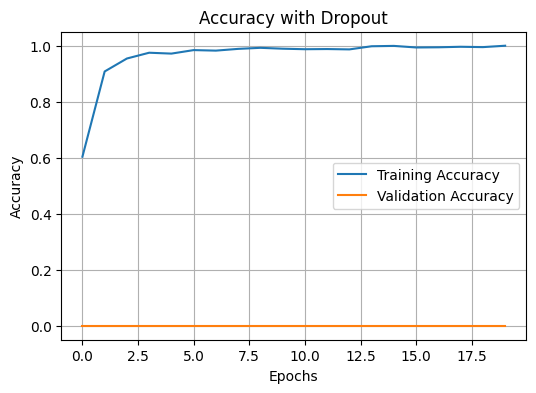

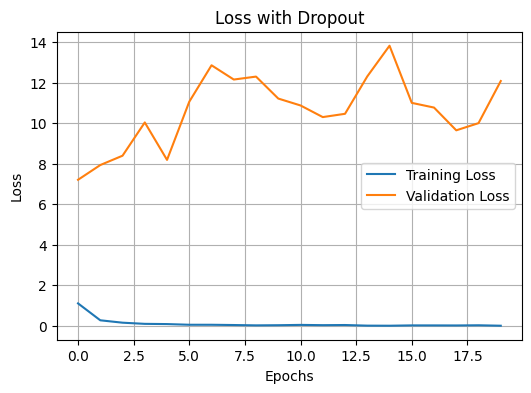

Test Accuracy (Dropout Model): 77.89%
Test Loss (Dropout Model): 2.3964


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# ----------------- STEP 1: Load MNIST -----------------
(x_train, y_train), _ = tf.keras.datasets.mnist.load_data()

# Select 200 images per digit → total 2000 images
selected_x, selected_y = [], []

for digit in range(10):
    idx = np.where(y_train == digit)[0][:200]
    selected_x.append(x_train[idx])
    selected_y.append(y_train[idx])

x = np.concatenate(selected_x, axis=0)
y = np.concatenate(selected_y, axis=0)

print("Training Images shape:", x.shape)
print("Training Labels shape:", y.shape)

# ----------------- STEP 2: Preprocess -----------------
x = x.astype("float32") / 255.0
x = x[..., np.newaxis]  # add channel dimension (2000,28,28,1)
y = tf.keras.utils.to_categorical(y, 10)

# ----------------- STEP 3: Build CNN + DNN with Dropout -----------------
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

# ---------- CNN PART ----------
model.add(Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))   # 25% dropout

model.add(Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))   # 25% dropout

model.add(Flatten())

# ---------- DNN PART ----------
model.add(Dense(512, activation='relu'))
   # 50% dropout

model.add(Dense(512, activation='relu'))
  # 50% dropout

model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))    # 50% dropout

# ---------- OUTPUT ----------
model.add(Dense(10, activation='softmax'))

# ----------------- STEP 4: Compile -----------------
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# ----------------- STEP 5: Train -----------------
history = model.fit(x, y, epochs=20, batch_size=32, validation_split=0.2)

# ----------------- STEP 6: Model Summary -----------------
model.summary()

# ----------------- STEP 7: Plot Accuracy -----------------
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy with Dropout')
plt.legend()
plt.grid(True)
plt.show()

# ----------------- STEP 8: Plot Loss -----------------
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss with Dropout')
plt.legend()
plt.grid(True)
plt.show()

# ----------------- STEP 9: Test Accuracy -----------------
(x_test, y_test), _ = tf.keras.datasets.mnist.load_data()

# Preprocess test data exactly as training
x_test = x_test.astype("float32") / 255.0
x_test = x_test[..., np.newaxis]   # add channel
y_test = tf.keras.utils.to_categorical(y_test, 10)

# Evaluate on test data
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy (Dropout Model): {test_accuracy*100:.2f}%")
print(f"Test Loss (Dropout Model): {test_loss:.4f}")

**early stop in dropout**

Training Images shape: (2000, 28, 28)
Training Labels shape: (2000,)
Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - accuracy: 0.2007 - loss: 2.0667 - val_accuracy: 0.0000e+00 - val_loss: 6.5193
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 89ms/step - accuracy: 0.7439 - loss: 0.7848 - val_accuracy: 0.0000e+00 - val_loss: 7.9955
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.8897 - loss: 0.3144 - val_accuracy: 0.0000e+00 - val_loss: 8.5309
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - accuracy: 0.9300 - loss: 0.1936 - val_accuracy: 0.0000e+00 - val_loss: 8.0207


Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_36 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_36 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_37 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_18 (Flatten)            │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_72 (Dense)                │ (None, 512)            │     1,606,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_73 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_74 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_75 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,466,208 (24.67 MB)

 Trainable params: 2,155,402 (8.22 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,310,806 (16.44 MB)

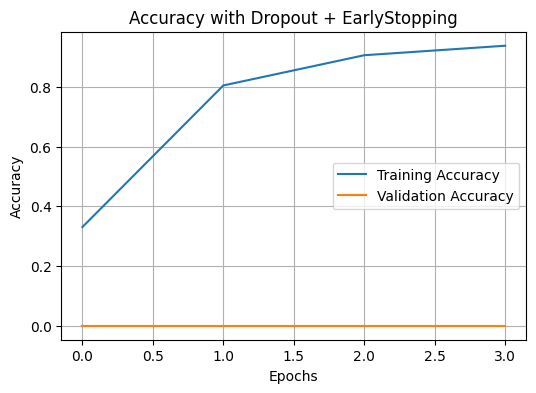

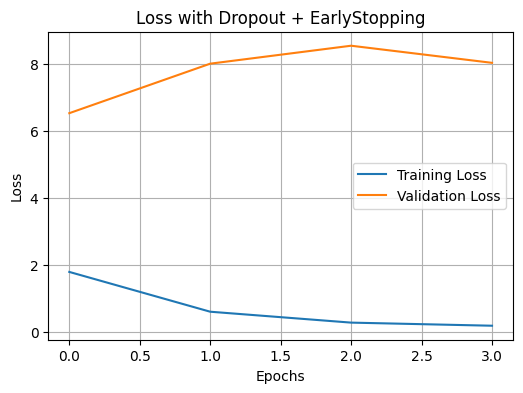

Test Accuracy (Dropout + EarlyStopping): 67.07%
Test Loss (Dropout + EarlyStopping): 1.9194


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# ----------------- STEP 1: Load MNIST -----------------
(x_train, y_train), _ = tf.keras.datasets.mnist.load_data()

# Select 200 images per digit → total 2000 images
selected_x, selected_y = [], []

for digit in range(10):
    idx = np.where(y_train == digit)[0][:200]
    selected_x.append(x_train[idx])
    selected_y.append(y_train[idx])

x = np.concatenate(selected_x, axis=0)
y = np.concatenate(selected_y, axis=0)

print("Training Images shape:", x.shape)
print("Training Labels shape:", y.shape)

# ----------------- STEP 2: Preprocess -----------------
x = x.astype("float32") / 255.0
x = x[..., np.newaxis]  # add channel dimension (2000,28,28,1)
y = tf.keras.utils.to_categorical(y, 10)

# ----------------- STEP 3: Build CNN + DNN with Dropout -----------------
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential()

# ---------- CNN PART ----------
model.add(Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

model.add(Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

model.add(Flatten())

# ---------- DNN PART ----------
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))

# ---------- OUTPUT ----------
model.add(Dense(10, activation='softmax'))

# ----------------- STEP 4: Compile -----------------
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# ----------------- STEP 5: Setup EarlyStopping -----------------
# Stop if validation loss does not improve for 3 epochs
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# ----------------- STEP 6: Train -----------------
history = model.fit(
    x, y,
    epochs=50,              # Max epochs, early stopping will likely stop earlier
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# ----------------- STEP 7: Model Summary -----------------
model.summary()

# ----------------- STEP 8: Plot Accuracy -----------------
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy with Dropout + EarlyStopping')
plt.legend()
plt.grid(True)
plt.show()

# ----------------- STEP 9: Plot Loss -----------------
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss with Dropout + EarlyStopping')
plt.legend()
plt.grid(True)
plt.show()

# ----------------- STEP 10: Test Accuracy -----------------
(x_test, y_test), _ = tf.keras.datasets.mnist.load_data()
x_test = x_test.astype("float32") / 255.0
x_test = x_test[..., np.newaxis]
y_test = tf.keras.utils.to_categorical(y_test, 10)

test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy (Dropout + EarlyStopping): {test_accuracy*100:.2f}%")
print(f"Test Loss (Dropout + EarlyStopping): {test_loss:.4f}")